In [1]:
%cd ..

C:\Users\apietka\PycharmProjects\accur8pool


In [3]:
from xgboost import XGBClassifier
from accur8pool.files_utils.filesManager import FilesManager
from sklearn.svm import SVC
from accur8pool.files_utils.dataFrameLoader import PandasDataFrameLoader
from accur8pool.data_processing.data_transformations import MlDataProcessor
from accur8pool.files_utils.utils import get_model_params
import time
import numpy as np
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.model_selection import train_test_split,ParameterSampler,TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.tree import DecisionTreeClassifier
from xgboost.callback import EarlyStopping
from sklearn.metrics import f1_score,recall_score,precision_score,balanced_accuracy_score
from accur8pool.data_processing.dataWindowing import DataWindowing,ExtractWindowFeatures
from accur8pool.data_processing.dataWindowing import CenterLabelingStrategy 
from collections import Counter
from pathlib import Path
import pandas as pd
import plotly.express as px

In [4]:
data_columns = ['accx', 'accy', 'accz', 'gyrx', 'gyry', 'gyrz', 'magx', 'magy', 'magz',
       'linaccx', 'linaccy', 'linaccz', 'rotx', 'roty', 'rotz',
       'acc_magnitude', 'gyr_magnitude','jerk_accx', 'jerk_accy',
       'jerk_accz', 'acc_magnitude_jerk', 'jerk_gyrx', 'jerk_gyry',
       'jerk_gyrz', 'gyr_magnitude_jerk', 'roll', 'pitch']



In [5]:
labels = list(Path(r'.\data\labeled_v2').rglob('*.csv'))
datas = list(Path(r'.\data\prepared').rglob('*.csv'))
labels

[WindowsPath('data/labeled_v2/data20260428_183042.csv'),
 WindowsPath('data/labeled_v2/data20260428_183747.csv'),
 WindowsPath('data/labeled_v2/data20260428_184848.csv'),
 WindowsPath('data/labeled_v2/data20260428_185945.csv'),
 WindowsPath('data/labeled_v2/data20260428_192054.csv'),
 WindowsPath('data/labeled_v2/data20260507_183754.csv'),
 WindowsPath('data/labeled_v2/data20260507_184346.csv'),
 WindowsPath('data/labeled_v2/data20260507_185142.csv'),
 WindowsPath('data/labeled_v2/data20260507_185428.csv'),
 WindowsPath('data/labeled_v2/data20260507_190258.csv'),
 WindowsPath('data/labeled_v2/data20260507_192012.csv'),
 WindowsPath('data/labeled_v2/data20260704_182159.csv')]

In [6]:
fileManager = FilesManager(labels_paths=labels,data_paths= datas)
dataLabelsPaths = fileManager.get_data_label_paths()
dataFrameLoader = PandasDataFrameLoader()
dataFrames = dataFrameLoader.load_data_labels_dfs(data_label_paths=dataLabelsPaths)
concated = dataFrameLoader.concat_datas_with_labels(data_labels_list=dataFrames)
concated['label']= concated['label'].fillna(0)
concated.shape

(792014, 35)

In [6]:
X = concated[data_columns].copy()
y= concated['label'].copy()
n= len(concated)
train_end_idx =int(n* 0.70)
test_end_idx= int(n*0.90)
X_train = X[:train_end_idx]
y_train = y[:train_end_idx]

X_test = X[train_end_idx:test_end_idx]
y_test = y[train_end_idx:test_end_idx]

X_eval = X[test_end_idx:]
y_eval = y[test_end_idx:]

X_train.shape,y_train.shape,X_test.shape,y_test.shape,X_eval.shape,y_eval.shape

((554409, 27), (554409,), (158403, 27), (158403,), (79202, 27), (79202,))

In [7]:
windowing = DataWindowing(window_size=20,window_step=3,labeling_strategy=CenterLabelingStrategy())
X_train_windowed, y_train_windowed = windowing.window_with_extractions(datas=X_train.to_numpy(),labels=y_train.to_numpy())

X_test_windowed, y_test_windowed = windowing.window_with_extractions(datas=X_test.to_numpy(),labels=y_test.to_numpy())

X_eval_windowed, y_eval_windowed = windowing.window_with_extractions(datas=X_eval.to_numpy(),labels=y_eval.to_numpy())

X_train_windowed.shape, y_train_windowed.shape,X_test_windowed.shape, y_test_windowed.shape,X_eval_windowed.shape, y_eval_windowed.shape

((184797, 189), (184797,), (52795, 189), (52795,), (26395, 189), (26395,))

In [8]:
counts = pd.Series(y_train_windowed).value_counts()
row_count = y_train_windowed.shape[0]
weights = {c:row_count/counts[c]*len(counts) for c in counts.keys()}
sample_weights = [weights[l] for l in y_train_windowed]
sample_weights

[np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float64(6.7453023024922985),
 np.float6

In [9]:
params = {'max_depth' : 6,'subsample':0.8,'learning_rate' : 0.1}
model = XGBClassifier(
        n_estimators=2000,
        early_stopping_rounds=10,
        eval_metric='mlogloss',
        objective="multi:softprob",
        num_class=5,
        **params,
        
    )

model.fit(
    X_train_windowed,
    y_train_windowed,
    sample_weight=sample_weights,
    eval_set=[(
        X_eval_windowed,
        y_eval_windowed
    )],

    verbose=True
)

[0]	validation_0-mlogloss:1.49637
[1]	validation_0-mlogloss:1.39698
[2]	validation_0-mlogloss:1.32538
[3]	validation_0-mlogloss:1.26536
[4]	validation_0-mlogloss:1.22590
[5]	validation_0-mlogloss:1.17641
[6]	validation_0-mlogloss:1.13337
[7]	validation_0-mlogloss:1.10166
[8]	validation_0-mlogloss:1.06554
[9]	validation_0-mlogloss:1.03390
[10]	validation_0-mlogloss:1.00432
[11]	validation_0-mlogloss:0.97760
[12]	validation_0-mlogloss:0.95372
[13]	validation_0-mlogloss:0.93125
[14]	validation_0-mlogloss:0.91170
[15]	validation_0-mlogloss:0.89517
[16]	validation_0-mlogloss:0.87885
[17]	validation_0-mlogloss:0.86467
[18]	validation_0-mlogloss:0.85147
[19]	validation_0-mlogloss:0.83923
[20]	validation_0-mlogloss:0.82760
[21]	validation_0-mlogloss:0.81530
[22]	validation_0-mlogloss:0.80560
[23]	validation_0-mlogloss:0.79593
[24]	validation_0-mlogloss:0.78662
[25]	validation_0-mlogloss:0.77727
[26]	validation_0-mlogloss:0.76798
[27]	validation_0-mlogloss:0.76161
[28]	validation_0-mlogloss:0.7

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [11]:
y_pred = model.predict(X_test_windowed)
f1 = f1_score(y_pred=y_pred,y_true=y_test_windowed,average="weighted")
f1

0.8828119753591231

In [69]:
from accur8pool.prepare_raw_data.prepare_raw_data import transform_raw_df
test_df = pd.read_csv(r'C:\Users\apietka\PycharmProjects\accur8pool\data\data\prepared\krzysiek\data20260704_182159.csv')
labels = pd.read_csv(r'C:\Users\apietka\PycharmProjects\accur8pool\data\data\labeled_v2\data20260704_182159.csv')['label']
labels=labels.fillna(0)
prepar = transform_raw_df(test_df)
windowed = windowing.window(prepar[data_columns].to_numpy())

ex =ExtractWindowFeatures() 
extracted = ex.extract(windowed)
y = model.predict(extracted)

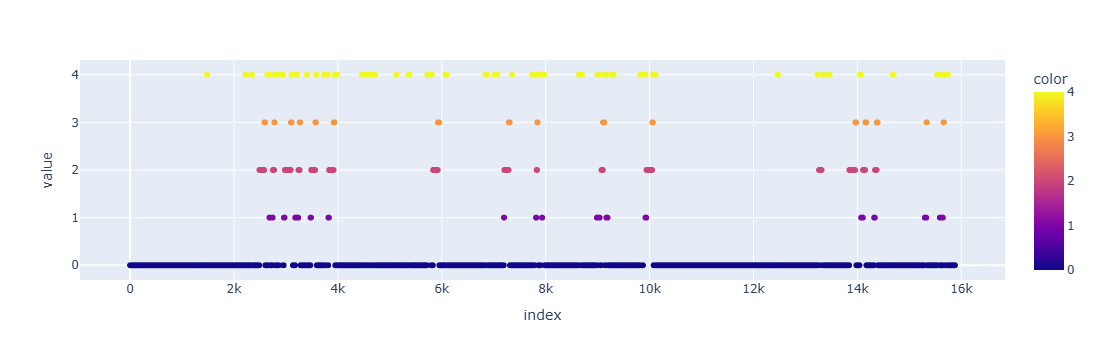

In [18]:
px.scatter(y_k_smothed,color=y_k_smothed)

In [261]:
st,sp = 3700,3900

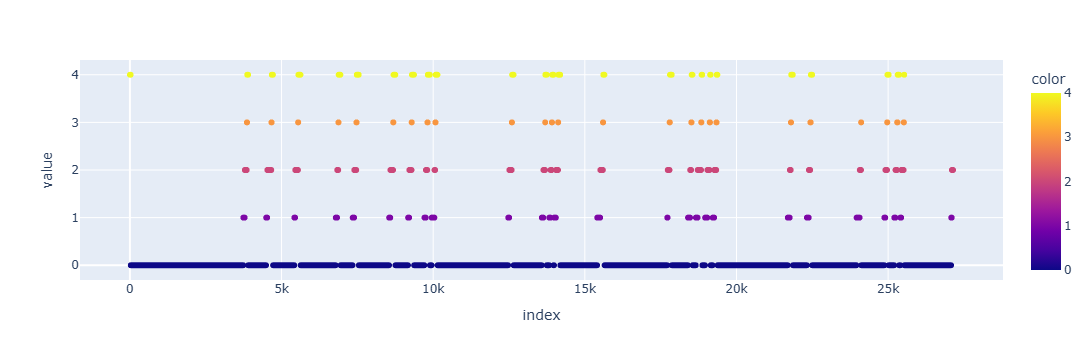

In [22]:
p_ref = y_test_windowed
px.scatter(p_ref,color=p_ref)

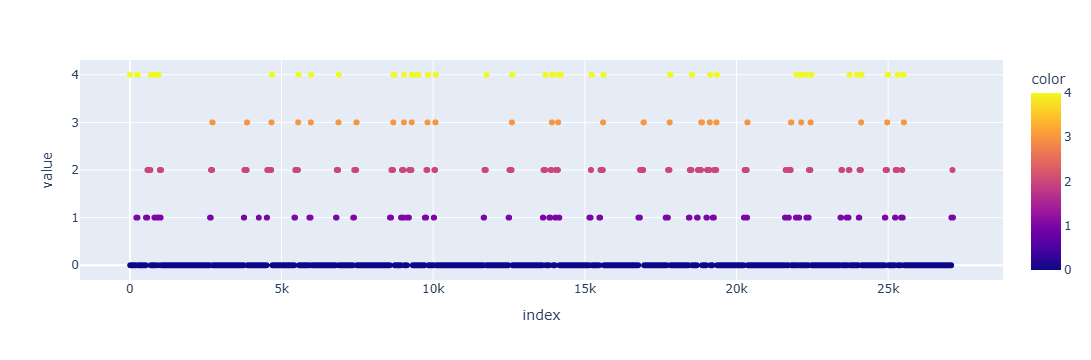

In [74]:
px.scatter(smoothed,color=smoothed)

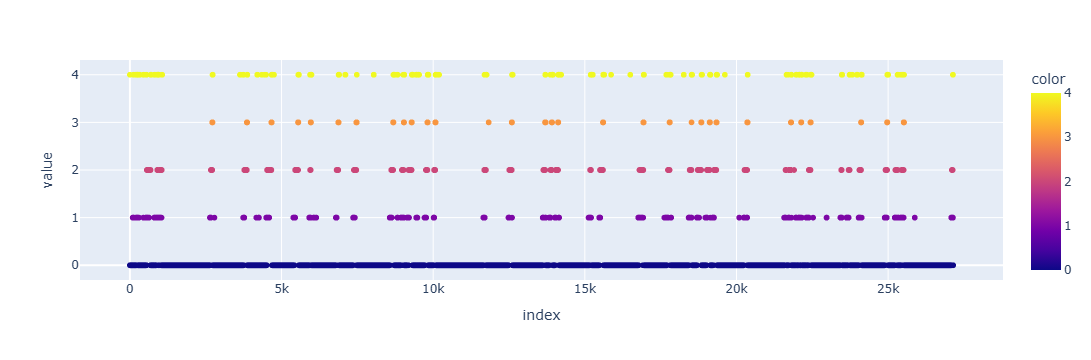

In [21]:
y_pred_ref= y_pred
import plotly.express as  px
px.scatter(y_pred_ref,color=y_pred_ref)

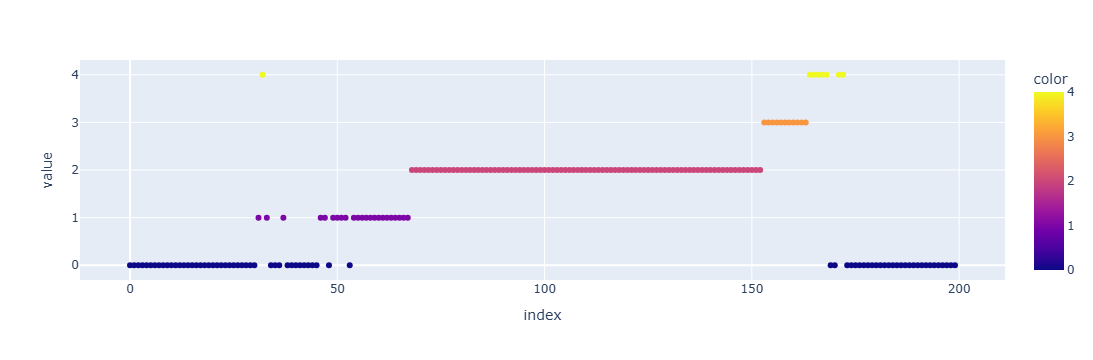

In [246]:
y1= y_pred[st:sp]
import plotly.express as  px
px.scatter(y1,color=y1)

In [17]:
import plotly.express as  px
y_smoothed = smoothed[st:sp]
px.scatter(y_smoothed,color=y_smoothed)

NameError: name 'st' is not defined

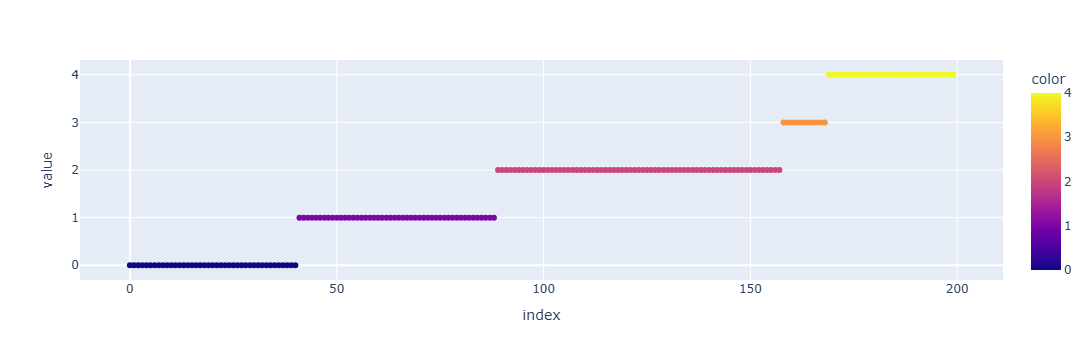

In [225]:
p = y_test_windowed[st:sp]
px.scatter(p,color=p)

In [14]:
def smooth(y_pred, min_group_size):
    y_pred = np.asarray(y_pred).copy()

    diff = np.diff(y_pred)
    switch_idx = np.where(diff != 0)[0] + 1
    switch_idx = np.r_[0, switch_idx, len(y_pred)]

    for start, end in zip(switch_idx[:-1], switch_idx[1:]):
        if start == 0:
            continue

        if end - start < min_group_size:
            y_pred[start:end] = y_pred[start - 1]

    return y_pred
smoothed= smooth(y_pred,7)

In [95]:
def onlyshot(y_pred):
    switch = np.where(np.diff(y_pred)!=0)[0] +1
    return switch

x=onlyshot(smoothed)
x

array([    6,   208,   231,   242,   253,   262,   528,   575,   680,
         689,   703,   804,   815,   822,   869,   921,   951,   959,
         982,  1005,  1017,  1030,  2640,  2671,  2714,  2730,  3753,
        3772,  3856,  3872,  4246,  4255,  4509,  4524,  4665,  4676,
        4697,  5421,  5448,  5544,  5555,  5573,  5914,  5960,  5971,
        5987,  6792,  6816,  6871,  6882,  6899,  7360,  7393,  7466,
        7481,  8573,  8616,  8679,  8690,  8724,  8936,  8970,  9022,
        9030,  9040,  9047,  9140,  9204,  9286,  9297,  9326,  9441,
        9453,  9509,  9518,  9719,  9771,  9809,  9819,  9845, 10014,
       10035, 10068, 10080, 10095, 11660, 11684, 11739, 11751, 11760,
       12483, 12510, 12589, 12600, 12620, 13611, 13634, 13697, 13712,
       13825, 13868, 13908, 13920, 13947, 14019, 14042, 14116, 14126,
       14143, 14163, 14206, 14218, 15147, 15194, 15211, 15235, 15474,
       15509, 15598, 15608, 15626, 16762, 16819, 16929, 16951, 17661,
       17669, 17711,

In [117]:
for i in range(0,len(x)-5,1):
    rang = x[i:i+5]
  
    if [smoothed[rang[0]],smoothed[rang[1]],smoothed[rang[2]],smoothed[rang[3]],smoothed[rang[4]]] == [1,2,3,4,0]:
        print(rang)

[4509 4524 4665 4676 4697]
[5421 5448 5544 5555 5573]
[6792 6816 6871 6882 6899]
[8573 8616 8679 8690 8724]
[9140 9204 9286 9297 9326]
[9719 9771 9809 9819 9845]
[10014 10035 10068 10080 10095]
[12483 12510 12589 12600 12620]
[13825 13868 13908 13920 13947]
[15474 15509 15598 15608 15626]
[17711 17742 17793 17804 17829]
[19004 19027 19114 19126 19142]
[19212 19259 19336 19346 19361]
[22378 22386 22440 22451 22475]
[24027 24054 24106 24116 24132]
[24886 24914 24965 24975 25001]


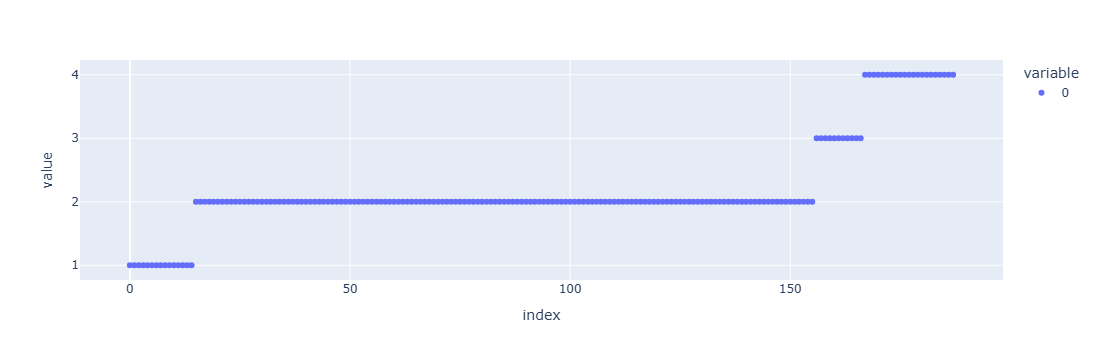

In [118]:
px.scatter(smoothed[4509:4697])

In [ ]:
y_pred = np.asarray(y_pred).copy()

diff = np.diff(y_pred)
switch_idx = np.where(diff != 0)[0] + 1
switch_idx = np.r_[0, switch_idx, len(y_pred)]


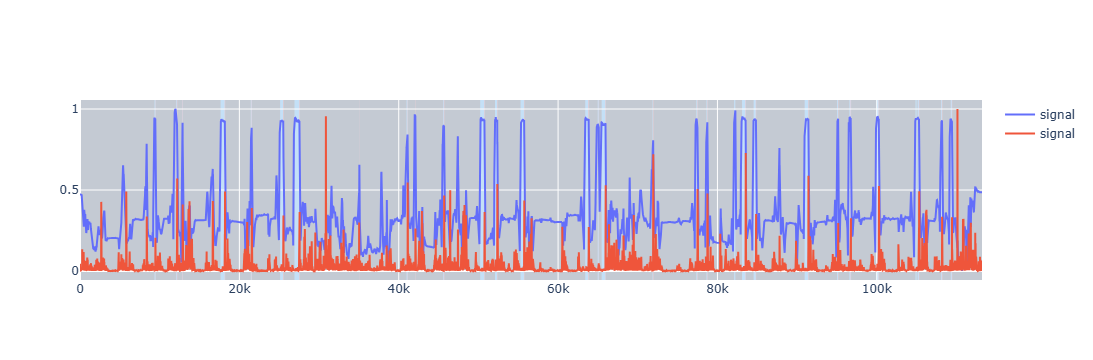

In [67]:
import plotly.graph_objects as go

def to_segments(labels):
    labels = np.asarray(labels)

    change = np.where(labels != np.roll(labels, 1))[0]
    change = np.r_[0, change, len(labels)]

    segments = []
    for i in range(len(change) - 1):
        start = change[i]
        end = change[i + 1]
        label = labels[start]
        segments.append((start, end, label))

    return segments
    
def plot(signal, labels,columns):
    fig = go.Figure()
    x = np.arange(len(signal))
    
    # sygnał
    for col in columns:
        fig.add_trace(go.Scatter(
            x=x,
            y=signal[col],
            mode="lines",
            name="signal"
        ))

    segments = to_segments(labels)

    colors = {
        0: "rgba(0,0,0,0.20)",
        1: "rgba(102, 255, 51,0.20)",
        2: "rgba(0, 153, 255,0.20)",
        3: "rgba(255, 0, 0,0.20)",
        4: "rgba(255, 255, 153,0.20)",
    }

    for start, end, label in segments:
        fig.add_vrect(
            x0=start,
            x1=end,
            fillcolor=colors.get(label, "rgba(0,0,0,0.1)"),
            opacity=0.7,
            line_width=0,
            layer="below"
        )

    fig.show()
smoothed= smooth(y,7)
reversed_=windowing.reverse_window_labels(smoothed,len(test_df))
cols = ['roll','acc_magnitude_jerk']
X = test_df[cols]
df_scaled = (X - X.min()) / (X.max() - X.min() + 1e-9)
plot(df_scaled,reversed_,columns=cols)